# Importing all modules we need

In [15]:
import math

import pandas as pd
import os

# Loading all files we will need later on


In [31]:
path_fitts = os.path.join('task_2_fitts_law', 'results')
path_steering = os.path.join('task_3_steering_law', 'results')

files_fitts = [file for file in os.listdir(path_fitts) if file.endswith('.csv')]
files_steering = [file for file in os.listdir(path_steering) if file.endswith('.csv')]

dfs_fitts = []

for file in files_fitts:
    path = os.path.join(path_fitts, file)
    dfs_fitts.append(pd.read_csv(path))

df_fitts = pd.concat(dfs_fitts, ignore_index=True)

dfs_steering = []

for file in files_steering:
    path = os.path.join(path_steering, file)
    dfs_steering.append(pd.read_csv(path))

df_steering = pd.concat(dfs_steering, ignore_index=True)

In [17]:
print(df_fitts)

     iteration part_id input_method  delay  num_targets  radius  distance  \
0            0   marti        mouse      0            8      25       350   
1            0   marti        mouse      0            8      25       350   
2            0   marti        mouse      0            8      25       350   
3            0   marti        mouse      0            8      25       350   
4            0   marti        mouse      0            8      25       350   
..         ...     ...          ...    ...          ...     ...       ...   
935          2   marti     touchpad      0            8      55       550   
936          2   marti     touchpad      0            8      55       550   
937          2   marti     touchpad      0            8      55       550   
938          2   marti     touchpad      0            8      55       550   
939          2   marti     touchpad      0            8      55       550   

     target_id  hit      timestamp  
0            4    1  1782724307556  
1

In [18]:
df_steering

,iteration,part_id,input_method,delay,width,distance,errors,start_time,end_time
0,1,marti,mouse,0,100,400,0,1782725444821,1782725445508
1,2,marti,mouse,0,100,400,0,1782725447335,1782725447887
2,3,marti,mouse,0,100,400,0,1782725450924,1782725451761
3,1,marti,mouse,0,100,600,0,1782725424378,1782725425555
4,2,marti,mouse,0,100,600,0,1782725429139,1782725430799
...,...,...,...,...,...,...,...,...,...
103,2,marti,touchpad,0,60,600,0,1782725646884,1782725647973
104,3,marti,touchpad,0,60,600,0,1782725650406,1782725652016
105,1,marti,touchpad,0,60,800,0,1782725681674,1782725684166
106,2,marti,touchpad,0,60,800,0,1782725686232,1782725687891


In [39]:
fitts_runs_df = (
    df_fitts
    .groupby(
        [
            "part_id",
            "input_method",
            "delay",
            "radius",
            "distance",
            "iteration",
        ],
        as_index=False,
    )
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        num_clicks=("hit", "count"),
        num_hits = ("hit", "sum"),
        num_targets=("target_id", "count"),
    )
)

fitts_runs_df["duration_ms"] = (
    fitts_runs_df["end_time"] - fitts_runs_df["start_time"]
)

fitts_runs_df['accuracy'] = (
    fitts_runs_df['num_hits'] / fitts_runs_df['num_targets']
)

print(fitts_runs_df)

    part_id input_method  delay  radius  distance  iteration     start_time  \
0     marti        mouse      0      25       350          0  1782724307556   
1     marti        mouse      0      25       350          1  1782724312974   
2     marti        mouse      0      25       350          2  1782724318620   
3     marti        mouse      0      25       450          0  1782724177333   
4     marti        mouse      0      25       450          1  1782724185891   
..      ...          ...    ...     ...       ...        ...            ...   
103   marti     touchpad      0      55       450          1  1782724585521   
104   marti     touchpad      0      55       450          2  1782724591670   
105   marti     touchpad      0      55       550          0  1782724623189   
106   marti     touchpad      0      55       550          1  1782724630168   
107   marti     touchpad      0      55       550          2  1782724637945   

          end_time  num_clicks  num_hits  num_targe

In [40]:
mean_df_fitts = (
    fitts_runs_df.groupby(
        ['part_id', 'input_method', 'delay', 'radius', 'distance'], as_index=False
    ).agg(
        mean_duration=("duration_ms", "mean"),
        mean_accuracy=("accuracy", "mean"),
    )
)

mean_df_fitts['mean_duration_seconds'] = (mean_df_fitts['mean_duration'] / 1000).round(2)
mean_df_fitts['no_errors'] = mean_df_fitts['mean_accuracy'] == 1

In [41]:
print(mean_df_fitts)

   part_id input_method  delay  radius  distance  mean_duration  \
0    marti        mouse      0      25       350    4084.666667   
1    marti        mouse      0      25       450    4992.333333   
2    marti        mouse      0      25       550    4710.666667   
3    marti        mouse      0      40       350    3400.333333   
4    marti        mouse      0      40       450    4141.000000   
5    marti        mouse      0      40       550    4435.000000   
6    marti        mouse      0      55       350    3094.000000   
7    marti        mouse      0      55       450    3359.666667   
8    marti        mouse      0      55       550    3914.000000   
9    marti        mouse    150      25       350    5907.333333   
10   marti        mouse    150      25       450    5938.333333   
11   marti        mouse    150      25       550    6709.000000   
12   marti        mouse    150      40       350    5624.333333   
13   marti        mouse    150      40       450    5791.66666

In [42]:
mean_fitts_combined = mean_df_fitts.groupby(
    ['part_id', 'input_method', 'delay'], as_index=False
).agg(
    total_mean_duration=("mean_duration_seconds", "mean"),
    total_mean_accuracy=("mean_accuracy", "mean"),
    total_no_errors=("no_errors", "sum")
)

print(mean_fitts_combined)

  part_id input_method  delay  total_mean_duration  total_mean_accuracy  \
0   marti        mouse      0             4.012222             0.987654   
1   marti        mouse    150             5.926667             0.980247   
2   marti         pose      0            16.980000             0.797498   
3   marti     touchpad      0             5.125556             0.992593   

   total_no_errors  
0                7  
1                6  
2                0  
3                8  


In [47]:
mean_fitts_final = mean_fitts_combined.groupby(
    ['input_method', 'delay'], as_index=False
).agg(
    mean_duration=("total_mean_duration", "mean"),
    mean_accuracy=("total_mean_accuracy", "mean"),
)
mean_fitts_final['mean_duration'] = mean_fitts_final['mean_duration'].round(2)
print(mean_fitts_final)

  input_method  delay  mean_duration  mean_accuracy
0        mouse      0           4.01       0.987654
1        mouse    150           5.93       0.980247
2         pose      0          16.98       0.797498
3     touchpad      0           5.13       0.992593


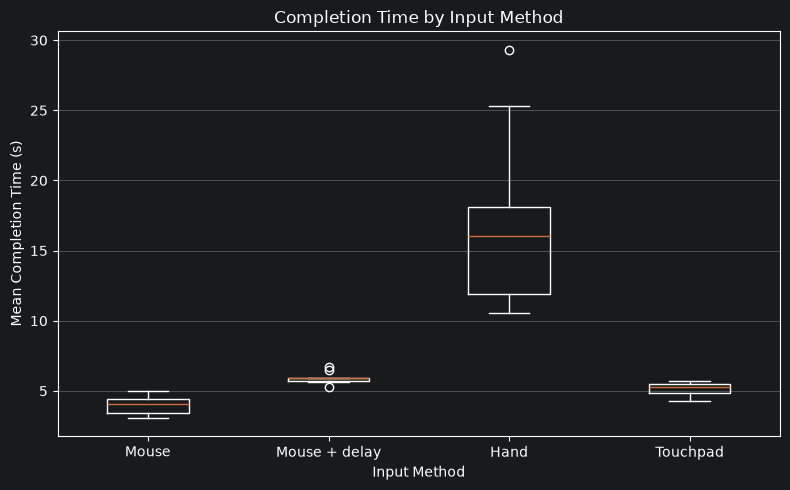

In [56]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] == 0)
    ]["mean_duration_seconds"],

    "Mouse + delay": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] > 0)
    ]["mean_duration_seconds"],

    "Hand": mean_df_fitts[
        mean_df_fitts["input_method"] == "pose"
    ]["mean_duration_seconds"],

    "Touchpad": mean_df_fitts[
        mean_df_fitts["input_method"] == "touchpad"
    ]["mean_duration_seconds"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())
plt.title("Completion Time by Input Method")
plt.xlabel("Input Method")
plt.ylabel("Mean Completion Time (s)")
plt.grid(axis="y")
plt.tight_layout()
plt.show()

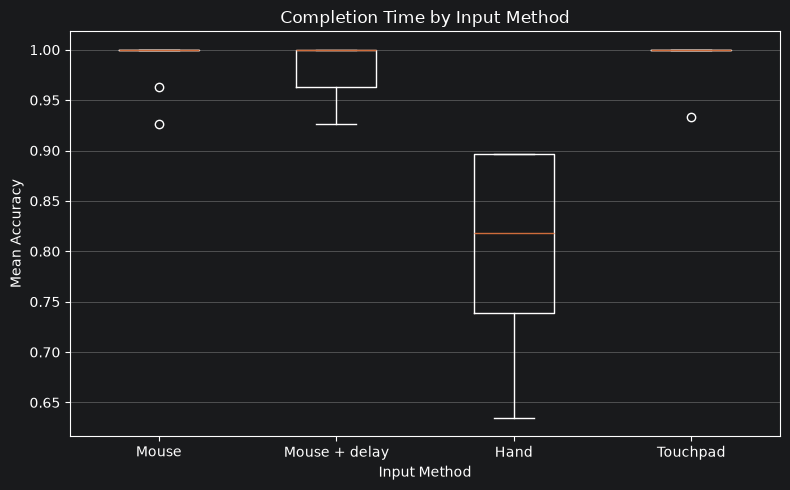

In [57]:
import matplotlib.pyplot as plt

plot_data = {
    "Mouse": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] == 0)
    ]["mean_accuracy"],

    "Mouse + delay": mean_df_fitts[
        (mean_df_fitts["input_method"] == "mouse") &
        (mean_df_fitts["delay"] > 0)
    ]["mean_accuracy"],

    "Hand": mean_df_fitts[
        mean_df_fitts["input_method"] == "pose"
    ]["mean_accuracy"],

    "Touchpad": mean_df_fitts[
        mean_df_fitts["input_method"] == "touchpad"
    ]["mean_accuracy"],
}

plt.figure(figsize=(8, 5))
plt.boxplot(plot_data.values(), tick_labels=plot_data.keys())
plt.title("Completion Time by Input Method")
plt.xlabel("Input Method")
plt.ylabel("Mean Accuracy")
plt.grid(axis="y")
plt.tight_layout()
plt.show()